In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 
from data_processing.processing.figure_of_merit import fit_fom, FOM, gaussian, n_sigma_classifier
from data_processing.reporting.plotting import plot_fom, plot_scatter, plot_classification_with_grouping
from scipy.optimize import curve_fit

In [2]:
EXP_NAME = "echem_exp"
ROOT = Path("C:/Users/Neutron Computer/Desktop/MATLAB Results/Maddy's experiment Oct 14, 22") / EXP_NAME
AMPLITUDES_PATH = ROOT / "amplitudes.csv"
PSD_PATH =  ROOT / "psd.csv"

In [3]:
psd = pd.read_csv(PSD_PATH, header=None)
amplitudes = pd.read_csv(AMPLITUDES_PATH, header=None)
psd_report = pd.concat([psd, amplitudes], axis=1)
psd_report.columns = ["tail / total", "amplitude"]

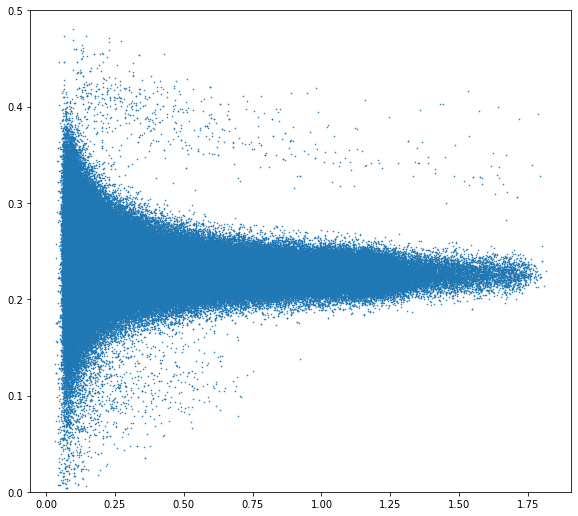

In [4]:
fig, ax = plot_scatter(psd_report["amplitude"], psd_report["tail / total"])
ax.set_ylim(0,0.5)
fig.set_figheight(7)
fig.set_figwidth(8)

In [33]:
cutoff_voltage = 0.25
# restricted = psd_report[psd_report["tail / total"].between(0, 0.5)]
restricted = psd_report[psd_report["amplitude"] >= cutoff_voltage]

In [34]:
def fit_gauss(counts, bins):
    params, cov = curve_fit(gaussian, bins[:-1], counts)
    return abs(params), cov

In [35]:
gamma_counts, gamma_bins = np.histogram(restricted["tail / total"], 100)
gamma_params, cov = fit_gauss(gamma_counts, gamma_bins)

In [36]:
n_sigma_window = 8

neutrons, gammas = n_sigma_classifier(
    restricted.T, gamma_params, n_sigma_window
)

(<Figure size 864x648 with 1 Axes>,
 <AxesSubplot:title={'center':'Neutron Classification at n=8 and cutoff = 0.250V'}, xlabel='pulse amplitude ($V$)', ylabel='tail / total (a.u.)'>)

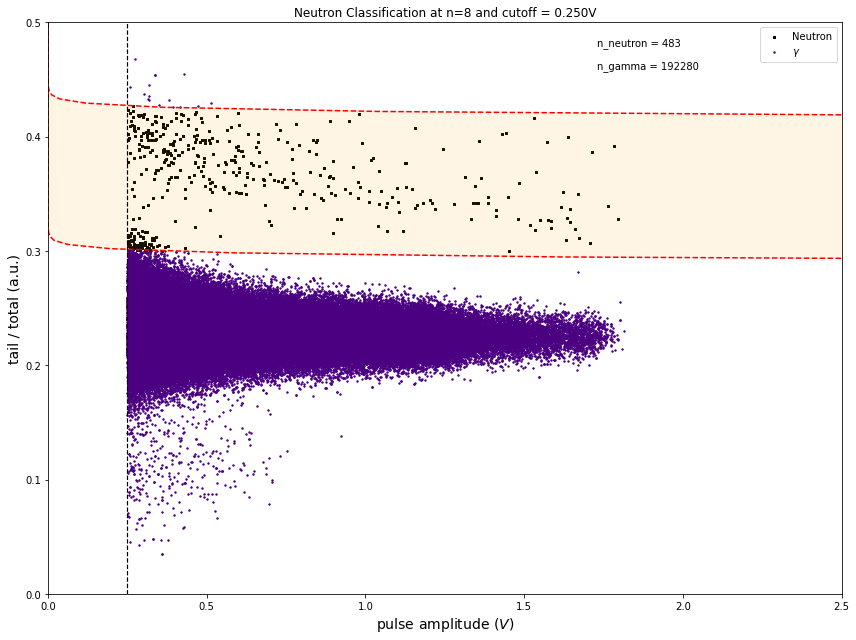

In [37]:
plot_classification_with_grouping(
    neutrons, gammas, gamma_params, restricted["amplitude"].max(), cutoff_voltage, n_sigma_window
)

In [481]:
rounded_psd = psd_report.copy()
rounded_psd["tail / total"] = rounded_psd["tail / total"].apply(lambda x: round(x, 3))
scanning_window = rounded_psd[rounded_psd["tail / total"].between(.0, 0.4)]
grouped_max = scanning_window.groupby(["tail / total"], as_index=False)["amplitude"].max()

rounded_2 = psd_report.copy()
rounded_2["tail / total"] = rounded_2["tail / total"].apply(lambda x: round(x, 2))
scanning_window_min = rounded_2[rounded_2["tail / total"].between(.13, 0.32)]
grouped_min = scanning_window.groupby(["tail / total"], as_index=False)["amplitude"].min()

avg_min = grouped_min.mean()["amplitude"]

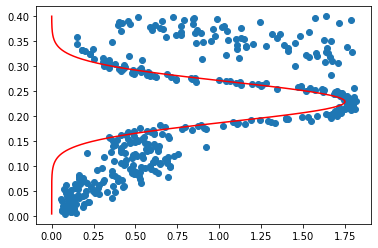

In [486]:
corr_fac = 0.07
params, cov = curve_fit(
    gaussian,
    grouped_max["tail / total"], 
    grouped_max["amplitude"] + avg_min + corr_fac,
    bounds=((0.20,0.01,1.3),(0.25,0.04,1.75))
)

plt.scatter(grouped_max["amplitude"], grouped_max["tail / total"])
plt.plot(gaussian(grouped_max["tail / total"], *params), grouped_max["tail / total"], 'r-')

Text(72.75, 0.5, 'PSD')

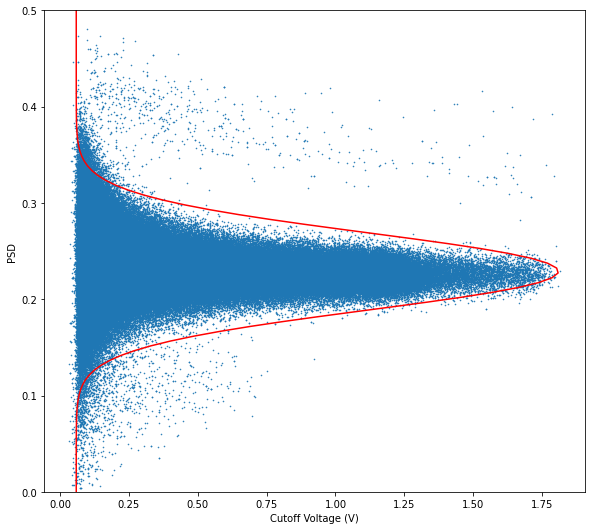

In [488]:
fig, ax = plot_scatter(psd_report["amplitude"], psd_report["tail / total"])
p = np.linspace(0,0.5,100)
ax.plot(gaussian(p, *params) + avg_min , p, 'r-')

ax.set_ylim(0,0.5)
fig.set_figheight(7)
fig.set_figwidth(8)
ax.set_xlabel("Cutoff Voltage (V)")
ax.set_ylabel("PSD")